## biblioteke

In [1]:
import os
import h5py
import pandas as pd

BASE_DIR = './MillionSongSubset'

In [94]:
from implicit.als import AlternatingLeastSquares
import pickle

## ucitavanje seta

In [2]:
df_fin = pd.read_csv('mergeovan.csv')

display(df_fin.head())

,user_id,song_id,play_count,artist_name,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOWEZSI12A81C21CE6,1,NaN,AR2UQQ51187B9AC816,"['flamenco', 'soundtrack', 'folk', 'spanish', ...",0.828210,0.627810,1,"['AR9Z7JB1187B99DB3D', 'ARC1SF21187FB51D0F', '..."
1,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SODCXXY12AB0187452,2,NaN,ARXLMH011C8A415658,"['pop rap', 'crunk', 'rapcore', 'screamo', 'br...",0.767205,0.455096,4,"['ARHAUVU122BCFCBA38', 'AR258TI11C8A416B5B', '..."
2,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SOWPAXV12A67ADA046,18,NaN,ARUQ6301187FB54EBA,"['pop rap', 'hip hop', 'hip house', 'new jack ...",0.880595,0.485477,4,"['ARNHMFD1187FB3B3F6', 'ARELPXQ1187FB384FD', '..."
3,b64cdd1a0bd907e5e00b39e345194768e330d652,SOLXDDC12A6701FBFD,1,NaN,ARTH9041187FB43E1F,"['hip hop', 'rap', 'hardcore rap', 'club', 'so...",0.912755,0.685498,4,"['AR23C041187FB4D534', 'ARZER7I1187FB385AF', '..."
4,b64cdd1a0bd907e5e00b39e345194768e330d652,SONJBQX12A6D4F8382,4,NaN,ARF8HTQ1187B9AE693,"['techno', 'electronica', 'electronic', 'pop',...",0.893026,0.423094,4,"['AR3NPVS1187FB5108F', 'ARMKBL21187FB38230', '..."


In [3]:
print(df_fin['song_id'].nunique())

2700


In [13]:
df_finalni = df_fin.drop(columns=["artist_name"]).copy()

df_finalni.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOWEZSI12A81C21CE6,1,AR2UQQ51187B9AC816,"['flamenco', 'soundtrack', 'folk', 'spanish', ...",0.828210,0.627810,1,"['AR9Z7JB1187B99DB3D', 'ARC1SF21187FB51D0F', '..."
1,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SODCXXY12AB0187452,2,ARXLMH011C8A415658,"['pop rap', 'crunk', 'rapcore', 'screamo', 'br...",0.767205,0.455096,4,"['ARHAUVU122BCFCBA38', 'AR258TI11C8A416B5B', '..."
2,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SOWPAXV12A67ADA046,18,ARUQ6301187FB54EBA,"['pop rap', 'hip hop', 'hip house', 'new jack ...",0.880595,0.485477,4,"['ARNHMFD1187FB3B3F6', 'ARELPXQ1187FB384FD', '..."
3,b64cdd1a0bd907e5e00b39e345194768e330d652,SOLXDDC12A6701FBFD,1,ARTH9041187FB43E1F,"['hip hop', 'rap', 'hardcore rap', 'club', 'so...",0.912755,0.685498,4,"['AR23C041187FB4D534', 'ARZER7I1187FB385AF', '..."
4,b64cdd1a0bd907e5e00b39e345194768e330d652,SONJBQX12A6D4F8382,4,ARF8HTQ1187B9AE693,"['techno', 'electronica', 'electronic', 'pop',...",0.893026,0.423094,4,"['AR3NPVS1187FB5108F', 'ARMKBL21187FB38230', '..."


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_finalni[['time_signature']] = scaler.fit_transform(df_finalni[['time_signature']])

display(df_finalni.head())

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOWEZSI12A81C21CE6,1,AR2UQQ51187B9AC816,"['flamenco', 'soundtrack', 'folk', 'spanish', ...",0.828210,0.627810,0.142857,"['AR9Z7JB1187B99DB3D', 'ARC1SF21187FB51D0F', '..."
1,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SODCXXY12AB0187452,2,ARXLMH011C8A415658,"['pop rap', 'crunk', 'rapcore', 'screamo', 'br...",0.767205,0.455096,0.571429,"['ARHAUVU122BCFCBA38', 'AR258TI11C8A416B5B', '..."
2,4bd88bfb25263a75bbdd467e74018f4ae570e5df,SOWPAXV12A67ADA046,18,ARUQ6301187FB54EBA,"['pop rap', 'hip hop', 'hip house', 'new jack ...",0.880595,0.485477,0.571429,"['ARNHMFD1187FB3B3F6', 'ARELPXQ1187FB384FD', '..."
3,b64cdd1a0bd907e5e00b39e345194768e330d652,SOLXDDC12A6701FBFD,1,ARTH9041187FB43E1F,"['hip hop', 'rap', 'hardcore rap', 'club', 'so...",0.912755,0.685498,0.571429,"['AR23C041187FB4D534', 'ARZER7I1187FB385AF', '..."
4,b64cdd1a0bd907e5e00b39e345194768e330d652,SONJBQX12A6D4F8382,4,ARF8HTQ1187B9AE693,"['techno', 'electronica', 'electronic', 'pop',...",0.893026,0.423094,0.571429,"['AR3NPVS1187FB5108F', 'ARMKBL21187FB38230', '..."


## podela train test val

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

izvor_interakcija = df_finalni

train_list = []
val_list = []
test_list = []

for user_id, group in izvor_interakcija.groupby("user_id"):
    n_samples = len(group)
    group_shuffled = group.sample(frac=1, random_state=42) # Uvek prvo mešamo

    # 1. korisnici sa 6 ili više pesama (70% train, 15% val, 15% test)
    if n_samples >= 6:
        train_temp, test_val = train_test_split(group, test_size=0.30, random_state=42)
        val, test = train_test_split(test_val, test_size=0.50, random_state=42) # Delimo onih 30% na pola
        
        train_list.append(train_temp)
        val_list.append(val)
        test_list.append(test)

    # 2. korisnici sa 3, 4 ili 5 pesama (1 train, 1 val, 1 test, ostatak u train)
    elif 3 <= n_samples <= 5:
        u_train = group_shuffled.iloc[3:]
        u_val = group_shuffled.iloc[[1]]
        u_test = group_shuffled.iloc[[2]]
        
        train_list.append(u_train)
        val_list.append(u_val)
        test_list.append(u_test)

    # 3. korisnici sa tačno 2 pesme (1 train, 1 test, val ostaje prazan)
    elif n_samples == 2:
        u_train = group_shuffled.iloc[[0]]
        u_test = group_shuffled.iloc[[1]]
        
        train_list.append(u_train)
        test_list.append(u_test)

    # 4. korisnici sa samo 1 pesmom (sve ide u train)
    else:
        train_list.append(group)

df_train = pd.concat(train_list, ignore_index=True)
df_val = pd.concat(val_list, ignore_index=True)
df_test = pd.concat(test_list, ignore_index=True)

print(f"Train: {df_train.shape[0]}, Val: {df_val.shape[0]}, Test: {df_test.shape[0]}")

Train: 168633, Val: 40419, Test: 54319


In [22]:
df_train.sample(5)

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
14022,82c9e891daf1ca9ec12c99212d5c39b80546369c,SONQBUB12A6D4F8ED0,6,ARFCUN31187B9AD578,"['blues', 'hard rock', 'rock', 'england', 'lon...",0.790764,0.530130,0.142857,"['ARSAIUN1187FB398D3', 'ARC73361187B9B42BD', '..."
53949,JM,SOPIFJT12A81C221AC,1,ARAZCWP129462A97F1,"['reggae', 'roots reggae', 'rock steady', 'dan...",0.817560,0.565708,0.571429,"['ARVIZLO1187FB3DA48', 'ARGPGVF11C8A4151E4', '..."
35896,Collab,SOAOPCG12AC468D27E,1,ARH6W4X1187B99274F,"['british pop', 'experimental rock', 'rock', '...",0.766266,0.467344,0.571429,"['ARN5NHX1187FB4F755', 'ARFC93D1187FB49D2E', '..."
92863,Slow jams,SOUVKXW12A8C1427AC,1,ARPDVPJ1187B9ADBE9,"['hip hop', 'r&b', 'ballad', 'gangster rap', '...",0.911778,0.563026,0.571429,"['ARAWOLW1187FB3AB70', 'ARLMXEA1187B9A7D04', '..."
83664,Roadtrip,SOOXLKF12A6D4F594A,1,ARF5M7Q1187FB501E8,"['pop', 'rock', 'alternative', 'modern rock', ...",0.898044,0.570400,0.571429,"['ARY53RR1187B9AE485', 'ARVLXWP1187FB5B94A', '..."


In [23]:
df_test.sample(5)

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
374,$$hoe anthems$$,SORZCIC12A6310ECC9,1,ARVBRGZ1187FB4675A,"['rock', 'pop', 'ballad', 'club', 'grunge']",0.918616,0.517616,0.571429,"['ARTDQRC1187FB4EFD4', 'ARAOYXM1187FB524F6', '..."
9573,Childhood,SOFQBMN12A8C1428AD,1,AR65K7A1187FB4DAA4,"['hip hop', 'pop', 'rock', 'soul', 'adult cont...",0.862878,0.319981,0.142857,"['ART4QZC1187FB51612', 'ARKSZW81187B9B695D', '..."
3000,5fc7d10b20b563cc6975ebcc7fa832a33288dbbc,SOHMBBX12A58A7926C,3,AR74Q3R1187B9B24C3,"['sympho black metal', 'progressive metal', 'h...",0.875749,0.296795,0.714286,"['ARRHD2X1187B9B389E', 'ARB1EH51187B9AD122', '..."
45367,new,SOSTXYN12A6D4F67D4,1,AR82DJK1187B991107,"['rap', 'hip hop', 'new wave', 'electro', 'und...",0.871842,0.264709,0.428571,"['ARV4KO21187FB38008', 'AR4WHYC1187B9896E7', '..."
30473,Spring Break,SOPVXLX12A8C1402D5,1,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."


In [24]:
df_val.sample(5)

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
26430,Wedding Party,SOCWJDB12A58A776AF,1,ARWPYQI1187FB4D55A,"['dance pop', 'rock', 'pop', 'england', 'adult...",0.840717,0.431305,0.571429,"['ARCJMMQ1187B98D1FD', 'ARY7CAU1187B98A4F6', '..."
33039,mountains,SOPOPLW12A8C13A905,1,ARJV0U41187B9AB715,"['pop punk', 'punk', 'pop', 'punk pop', 'emo p...",0.818671,0.334641,0.571429,"['ARG72Q21187FB36243', 'ARW5QWS1187FB57C1B', '..."
233,#throwbackthursday,SOSGQPS12A8AE48538,1,ARXOTQH1187FB57084,"['r&b', 'hip hop', 'rap', 'urban', 'blues']",0.905342,0.532660,0.571429,"['ARAWOLW1187FB3AB70', 'ARF33H31187FB45223', '..."
24496,Throwback,SOKMBQK12A8C1450CE,1,ARPDVPJ1187B9ADBE9,"['hip hop', 'r&b', 'ballad', 'gangster rap', '...",0.880136,0.483035,0.714286,"['ARAWOLW1187FB3AB70', 'ARLMXEA1187B9A7D04', '..."
24547,Throwback,SOFIFUK12A8C1393F8,1,AR03BDP1187FB5B324,"['dance pop', 'teen pop', 'pop rock', 'electro...",0.917562,0.324665,0.428571,"['ARX6TAQ11C8A415850', 'ARY7CAU1187B98A4F6', '..."


In [25]:
df_train.to_csv('df_train.csv', index=False)

In [26]:
df_test.to_csv('df_test.csv', index=False)

In [27]:
df_val.to_csv('df_val.csv', index=False)

## prosirivanje train df

In [28]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer

df_sinteticki = df_train.copy()


df_pesme = df_sinteticki.drop_duplicates(subset=["song_id"]).copy()

df_pesme["artist_terms"] = df_pesme["artist_terms"].fillna("")

def osiguraj_listu(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x_clean = x.replace("[", "").replace("]", "").replace("'", "")
        if x_clean.strip() == "":
            return []
        return [tag.strip() for tag in x_clean.split(",") if tag.strip()]
    return []

df_pesme["artist_terms"] = df_pesme["artist_terms"].apply(osiguraj_listu)


num_kolone = ["loudness", "tempo", "time_signature"] ## dodaj mode pretposlednje
for kolona in num_kolone:
    medijana = df_pesme[kolona].median()
    df_pesme[kolona] = df_pesme[kolona].fillna(medijana)


mlb = MultiLabelBinarizer()
izrazi_kodirani = mlb.fit_transform(df_pesme["artist_terms"])
df_izrazi = pd.DataFrame(
    izrazi_kodirani, columns=mlb.classes_, index=df_pesme.index
)

scaler = MinMaxScaler()
audio_skalirano = scaler.fit_transform(df_pesme[num_kolone])
df_audio = pd.DataFrame(
    audio_skalirano, columns=num_kolone, index=df_pesme.index
)

X_features = pd.concat([df_audio, df_izrazi], axis=1)

pesma_indeks_mapa = df_pesme["song_id"].tolist()


k_susedi = 10
knn = NearestNeighbors(n_neighbors=k_susedi, metric="cosine")
knn.fit(X_features)

udaljenosti, indeksi = knn.kneighbors(X_features)

komsije_mape = {}
for i, song_id in enumerate(pesma_indeks_mapa):
    top_komsije_indeksi = indeksi[i][1:]
    top_komsije_id = [pesma_indeks_mapa[idx] for idx in top_komsije_indeksi]
    komsije_mape[song_id] = top_komsije_id

korisnik_slusao = (
    df_sinteticki.groupby("user_id")["song_id"].apply(set).to_dict()
)

meta_pesama_mapa = df_pesme.set_index("song_id").to_dict(orient="index")

jake_interakcije = df_sinteticki[df_sinteticki["play_count"] >= 2]

novi_redovi = []

for idx, row in jake_interakcije.iterrows():
    user = row["user_id"]
    trenutna_pesma = row["song_id"]

    potencijalne_komsije = komsije_mape.get(trenutna_pesma, [])
    vec_slusane = korisnik_slusao.get(user, set())

    for komsija_id in potencijalne_komsije:
        if komsija_id not in vec_slusane:
            meta = meta_pesama_mapa[komsija_id]

            sinteticki_red = {
                "user_id": user,
                "song_id": komsija_id,
                "play_count": 1,  
                "artist_id": meta["artist_id"],
                "artist_terms": meta["artist_terms"],
                "loudness": meta["loudness"],
                "tempo": meta["tempo"],
                #"mode": meta["mode"],
                "time_signature": meta["time_signature"],
                "similar_artists": meta["similar_artists"],
            }
            novi_redovi.append(sinteticki_red)

if novi_redovi:
    df_novi_podaci = pd.DataFrame(novi_redovi).drop_duplicates(
        subset=["user_id", "song_id"]
    )
    df_trainveci = pd.concat([df_sinteticki, df_novi_podaci], ignore_index=True)
    print(f"Uspešno dodato {len(df_novi_podaci)} novih objektivnih interakcija!")
else:
    df_trainveci = df_sinteticki.copy()
    print("Nije pronađena nijedna nova interakcija za dodavanje.")

n_users_novi = df_trainveci["user_id"].nunique()
n_items_novi = df_trainveci["song_id"].nunique()
nova_gustina = (len(df_trainveci) / (n_users_novi * n_items_novi)) * 100

print(f"Stari broj redova: {len(df_sinteticki)}")
print(f"Novi broj redova: {len(df_trainveci)}")
print(f"Nova gustina matrice je: {nova_gustina:.4f}%")

Uspešno dodato 31706 novih objektivnih interakcija!
Stari broj redova: 168633
Novi broj redova: 200339
Nova gustina matrice je: 0.3283%


In [29]:
print("broj pesama je", df_trainveci['song_id'].nunique())
print("broj usera je", df_trainveci['user_id'].nunique())
print("ukupno play countova", sum(df_trainveci['play_count']))
print("play count prosek po korisniku", sum(df_trainveci['play_count'])/df_trainveci['user_id'].nunique())
broj_interakcija = len(df_trainveci)
print("broj interakcija", broj_interakcija)
moguce_interakcije = df_trainveci['user_id'].nunique() * df_trainveci['song_id'].nunique()
gustina = (broj_interakcija / moguce_interakcije) * 100
print(f"Gustina matrice: {gustina:.4f}%")

broj pesama je 2262
broj usera je 26974
ukupno play countova 216384
play count prosek po korisniku 8.021947060131978
broj interakcija 200339
Gustina matrice: 0.3283%


In [30]:
print(max(df_train.play_count))
print(min(df_train.play_count))
print(sum(df_train.play_count))
print(len(df_train))
print(sum(df_train.play_count)/len(df_train))
print(df_train.play_count.median())

189
1
184678
168633
1.095147450380412
1.0


In [31]:
print(max(df_trainveci.play_count))
print(min(df_trainveci.play_count))
print(sum(df_trainveci.play_count))
print(len(df_trainveci))
print(sum(df_trainveci.play_count)/len(df_trainveci))
print(df_trainveci.play_count.median())

189
1
216384
200339
1.0800892487234137
1.0


In [32]:
df_train.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
0,bn,SOSKFIT12A8C14224A,1,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
1,2000s pop,SOPVXLX12A8C1402D5,1,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."
2,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
3,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
4,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."


In [33]:
df_trainveci.head()

,user_id,song_id,play_count,artist_id,artist_terms,loudness,tempo,time_signature,similar_artists
0,bn,SOSKFIT12A8C14224A,1,ARM7EDF1187B9B3FA1,"['heavy metal', 'hard rock', 'rock', 'metal', ...",0.914632,0.510554,1.000000,"['ARE8GLF1187FB52532', 'ARKUDKL1296AAF0B2F', '..."
1,2000s pop,SOPVXLX12A8C1402D5,1,AR3JMC51187B9AE49D,"['teen pop', 'pop', 'rock', 'adult contemporar...",0.891092,0.429129,0.571429,"['AR03BDP1187FB5B324', 'AR5YRCN1187B98E3C8', '..."
2,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
3,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."
4,60's,SONFECQ12AB017EFF7,1,AROCBZZ11E2835D652,"[""rock 'n roll"", 'blues-rock', 'british invasi...",0.823613,0.469436,0.571429,"['ARQNR1G1187B9AE88F', 'ARPISA41187FB3DE42', '..."


In [37]:
# stari
br_tr = sum(df_train.play_count)
br_te = sum(df_test.play_count)
br_va = sum(df_val.play_count)
ukupno = br_tr + br_te + br_va

print("--- stari skup ---")
print("train:", br_tr)
print("test:", br_te)
print("odnos, train:", (br_tr / ukupno) * 100, "%, test:", (br_te / ukupno) * 100, "%, val:", (br_va / ukupno) * 100, "%")

# veci
br_tr = sum(df_trainveci.play_count)
br_te = sum(df_test.play_count)
br_va = sum(df_val.play_count)
ukupno = br_tr + br_te + br_va

print('\n')
print("--- stari skup ---")
print("train:", br_tr)
print("test:", br_te)
print("odnos, train:", (br_tr / ukupno) * 100, "%, test:", (br_te / ukupno) * 100, "%, val:", (br_va / ukupno) * 100, "%")

--- stari skup ---
train: 184678
test: 59975
odnos, train: 64.18894025233742 %, test: 20.845643182371138 %, val: 14.96541656529144 %


--- stari skup ---
train: 216384
test: 59975
odnos, train: 67.74363212863476 %, test: 18.776454529516368 %, val: 13.479913341848873 %


In [35]:
df_trainveci.to_csv('df_trainveci.csv', index=False)

## brisanje podataka za als

In [38]:
df_train_als = df_train.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_train_als.sample(5)

,user_id,song_id,play_count
84129,Rock,SOSKFIT12A8C14224A,1
94487,Stay With Me,SOHTQAS12A6701C7BA,1
26629,Bring it Back,SOIJEWM12A67ADA08D,1
38716,Dinner,SODZIBG12A8C13F4F3,1
25356,Beyoncé,SOFQBMN12A8C1428AD,1


In [39]:
df_test_als = df_test.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_test_als.sample(5)

,user_id,song_id,play_count
44537,megan,SOMRYSL12AB01852A8,1
41417,favorite music,SOSKFIT12A8C14224A,1
23418,Oldies,SOQUAIH12AB0181406,1
20808,Music,SOSKFIT12A8C14224A,1
25998,Rainy day,SOUCKDH12A8C138FF5,1


In [40]:
df_val_als = df_val.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_val_als.sample(5)

,user_id,song_id,play_count
19632,Relaxing,SONJNMA12A6701DFDE,1
17150,Oldies,SOOTBSZ12A8C140223,1
10174,Feel Good Music,SOUXANT12A6D4FB048,1
24315,Throwback,SOSGQPS12A8AE48538,1
1200,2000s r&b,SOQCQNU12A8C138694,1


In [42]:
df_trainveci_als = df_trainveci.drop(columns=["artist_id", "artist_terms", "loudness", "tempo", "time_signature", "similar_artists"]).copy()
df_trainveci_als.sample(5)

,user_id,song_id,play_count
80810,Rappp,SOGRSAV12A6701FBBD,1
132345,hg,SOSKFIT12A8C14224A,1
114745,ae62418946650e2c35ff7e323c1b040af7c28d9e,SOAWCYO12A8151DF97,4
137196,mj,SOSTXYN12A6D4F67D4,1
146350,qwertyuiop,SOKHJSC12A8C14016E,1


## priprema podataka za als

In [44]:


# brisanje duplikata
df_als = df_trainveci_als.groupby(['user_id', 'song_id'])['play_count'].sum().reset_index()


user_cat = df_als['user_id'].astype('category')
song_cat = df_als['song_id'].astype('category')

# mapiranje
user_map = {cat: i for i, cat in enumerate(user_cat.cat.categories)}
song_map = {cat: i for i, cat in enumerate(song_cat.cat.categories)}

df_als['user_id_idx'] = df_als['user_id'].map(user_map)
df_als['song_id_idx'] = df_als['song_id'].map(song_map)

# mapiranje na val i test a koristimo mapiranje od traina
df_test_als = df_test.copy()
df_test_als['user_id_idx'] = df_test_als['user_id'].map(user_map)
df_test_als['song_id_idx'] = df_test_als['song_id'].map(song_map)
df_test_als = df_test_als.dropna(subset=['user_id_idx', 'song_id_idx'])

df_val_als = df_val.copy()
df_val_als['user_id_idx'] = df_val_als['user_id'].map(user_map)
df_val_als['song_id_idx'] = df_val_als['song_id'].map(song_map)
df_val_als = df_val_als.dropna(subset=['user_id_idx', 'song_id_idx'])

# sparse matrica za als
from scipy.sparse import csr_matrix

sparse_item_user = csr_matrix(
    (df_als['play_count'], (df_als['song_id_idx'], df_als['user_id_idx']))
)

print("Podaci su spremni!")
print(f"Dimenzije matrice: {sparse_item_user.shape}")
print(f"Train interakcije: {len(df_als)}, Test: {len(df_test_als)}, Val: {len(df_val_als)}")

Podaci su spremni!
Dimenzije matrice: (2262, 26974)
Train interakcije: 124640, Test: 50251, Val: 36505


## implementacija als

In [93]:
# ovde nema cuvanja modela po epohama, pokrece se kod ispod

# matrica user_id song_id 
'''user_item_matrix = sparse_item_user.T.tocsr()

# model inicijalizacija
model = AlternatingLeastSquares(factors=120, regularization=0.5, iterations=1) 

istorija_preciznosti = []

for i in range(20): # broj iteracija
    model.fit(user_item_matrix) 
    
    # evaluacija val set
    rezultati = []
    test_uzorak = df_val_als
    
    for _, row in test_uzorak.iterrows():
        u_idx = int(row['user_id_idx'])
        p_idx = int(row['song_id_idx'])
        
        if u_idx >= model.user_factors.shape[0]: continue
            
        recs = model.recommend(u_idx, user_item_matrix[u_idx], N=10, filter_already_liked_items=True)
        if p_idx in recs[0]:
            rezultati.append(1.0)
        else:
            rezultati.append(0.0)
            
    preciznost = sum(rezultati) / len(rezultati)
    istorija_preciznosti.append(preciznost)
    print(f"Iteracija {i+1}: Precision@10 = {preciznost:.4f}")

# grafik toka treninga
import matplotlib.pyplot as plt
plt.plot(range(1, 21), istorija_preciznosti, marker='o')
plt.xlabel('Iteracija')
plt.ylabel('Precision@10 na validaciji')
plt.title('Napredak modela kroz iteracije')
plt.show()'''

  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 1: Precision@10 = 0.0429


  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 2: Precision@10 = 0.1610


  0%|          | 0/1 [00:00<?, ?it/s]

...

Iteracija 4: Precision@10 = 0.1625


  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 5: Precision@10 = 0.1444


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 1: Precision@10 = 0.0405 - Sačuvano u sacuvani_modeli\model_f120_reg0.5\epoha_01.pkl


  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 2: Precision@10 = 0.1612 - Sačuvano u sacuvani_modeli\model_f120_reg0.5\epoha_02.pkl


  0%|          | 0/1 [00:00<?, ?it/s]

...

Iteracija 18: Precision@10 = 0.0597 - Sačuvano u sacuvani_modeli\model_f120_reg0.5\epoha_18.pkl


  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 19: Precision@10 = 0.0592 - Sačuvano u sacuvani_modeli\model_f120_reg0.5\epoha_19.pkl


  0%|          | 0/1 [00:00<?, ?it/s]

Iteracija 20: Precision@10 = 0.0587 - Sačuvano u sacuvani_modeli\model_f120_reg0.5\epoha_20.pkl


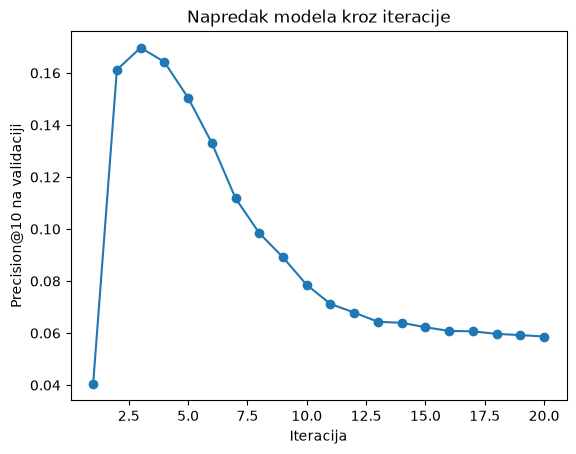

In [95]:
## kod gde se cuvaju modeli posle svake epohe

broj_faktora = 120
regularizacija = 0.5
ime_podfoldera = f'model_f{broj_faktora}_reg{regularizacija}'
putanja_foldera = os.path.join('sacuvani_modeli', ime_podfoldera)

if not os.path.exists(putanja_foldera):
    os.makedirs(putanja_foldera)

user_item_matrix = sparse_item_user.T.tocsr()

model = AlternatingLeastSquares(factors=broj_faktora, regularization=regularizacija, iterations=1) 

istorija_preciznosti = []

for i in range(1, 21): 
    model.fit(user_item_matrix) 
    
    # cuvanje modela
    ime_fajla = os.path.join(putanja_foldera, f'epoha_{i:02d}.pkl')
    with open(ime_fajla, 'wb') as f:
        pickle.dump(model, f)
    
    # evaluacija val set
    rezultati = []
    test_uzorak = df_val_als
    
    for _, row in test_uzorak.iterrows():
        u_idx = int(row['user_id_idx'])
        p_idx = int(row['song_id_idx'])
        
        if u_idx >= model.user_factors.shape[0]: continue
            
        recs = model.recommend(u_idx, user_item_matrix[u_idx], N=10, filter_already_liked_items=True)
        if p_idx in recs[0]:
            rezultati.append(1.0)
        else:
            rezultati.append(0.0)
            
    preciznost = sum(rezultati) / len(rezultati)
    istorija_preciznosti.append(preciznost)
    print(f"Iteracija {i}: Precision@10 = {preciznost:.4f} - Sačuvano u {ime_fajla}")

# grafik toka treninga
import matplotlib.pyplot as plt
plt.plot(range(1, 21), istorija_preciznosti, marker='o')
plt.xlabel('Iteracija')
plt.ylabel('Precision@10 na validaciji')
plt.title('Napredak modela kroz iteracije')
plt.show()

In [52]:
# prevodjenje onog mapiranja u song_id da mozemo da vidimo sta je preporucio
song_map_inverse = {v: k for k, v in song_map.items()}

preporuceni_indeksi = [14410, 24960, 5191, 9857, 6130, 5071, 17436, 11878, 18431,  5558] # primer
nazivi_pesama = [song_map_inverse[i] for i in preporuceni_indeksi]
print(f"Preporučene pesme za korisnika: {nazivi_pesama}")

KeyError: 14410

In [97]:
# ucitavanje modela

putanja_do_modela = 'sacuvani_modeli/model_f120_reg0.5/epoha_03.pkl'

with open(putanja_do_modela, 'rb') as f:
    model = pickle.load(f)

print(f"model {putanja_do_modela} je ucitan")

model sacuvani_modeli/model_f120_reg0.5/epoha_03.pkl je ucitan


In [98]:
# test - samo precision

user_item_matrix = sparse_item_user.T.tocsr()

# evaluacija na test skupu
rezultati = []
broj_korisnika_u_modelu = model.user_factors.shape[0]

for index, row in df_test_als.iterrows():
    u_idx = int(row['user_id_idx'])
    p_idx = int(row['song_id_idx'])
    
    if u_idx < 0 or u_idx >= broj_korisnika_u_modelu:
        continue 
        
    user_row = user_item_matrix[u_idx]
    
    recs = model.recommend(userid=u_idx, user_items=user_row, N=10, filter_already_liked_items=True)
    
    if p_idx in recs[0]:
        rezultati.append(1.0)
    else:
        rezultati.append(0.0)

# konacan rezultat
preciznost_ukupno = sum(rezultati) / len(rezultati)
print(f"Konačna Precision@10 na test setu: {preciznost_ukupno:.4f}")

Konačna Precision@10 na test setu: 0.2149


In [100]:
# test - precision, recall, f1, hit rate

user_item_matrix = sparse_item_user.T.tocsr()

# evaluacija na test skupu
rezultati = []
broj_korisnika_u_modelu = model.user_factors.shape[0]

for index, row in df_test_als.iterrows():
    u_idx = int(row['user_id_idx'])
    p_idx = int(row['song_id_idx'])
    
    if u_idx < 0 or u_idx >= broj_korisnika_u_modelu:
        continue 
        
    user_row = user_item_matrix[u_idx]
    
    recs = model.recommend(userid=u_idx, user_items=user_row, N=10, filter_already_liked_items=True)
    
    hit = 1.0 if p_idx in recs[0] else 0.0
    rezultati.append(hit)

# racunanje svih metrika
# formule

hit_rate = sum(rezultati) / len(rezultati) # Ovo je u redu (procenat korisnika kojima smo pogodili bar nešto)

# precision: Od 10 preporučenih, koliko je stvarno relevantno?
precision = sum(rezultati) / (len(rezultati) * 10) 

# recall: Od 1 relevantne pesme, koliko smo ih našli?
recall = sum(rezultati) / len(rezultati) 

# f1-score
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

# tabela sa rezultatima
metrics_df = pd.DataFrame({
    'Metrika': ['Precision@10', 'Recall@10', 'Hit Rate@10', 'F1-Score@10'],
    'Vrednost': [precision, recall, hit_rate, f1]
})

print("--- Finalni rezultati na test setu ---")
print(metrics_df.to_string(index=False))

--- Finalni rezultati na test setu ---
     Metrika  Vrednost
Precision@10  0.021492
   Recall@10  0.214921
 Hit Rate@10  0.214921
 F1-Score@10  0.039077
